# S2 | Question Sampling (v1 — historical)

> **Note:** This notebook documents the v1 sampling process (100 questions, inst_blind signal score).
> The current sample is **** (117 questions) generated by .
> Key changes in v2: blind-based signal score · 117 questions · yesno≤26 · COLOR_CAP=4 · ENT caps per group.

# S2 | Question Sampling

Designed and executed the **100-question S2 v1 sample** *(archived)* using a
signal-score-ranked 3×2 ent×op stratified design.

**Signal score (v1):**  *(v2 uses blind acc)*`0.7 · norm(inst_blind_acc) + 0.3 · norm(acc_range_ctrl)`  
**Caps:** `yesno=0` (excluded), `how_many≤15`  
**S1 exclusion:** 374 ACL study questions removed from pool  
**Output:** `experiment/s2.csv` + `experiment/s2_*.json`


In [1]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR    = '/home/david/Desktop/yuna/HPA/evaluation/logits/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

mapper = VQAAnswerMapper()

# Full 5-step degradation ladder (pronominalized now complete for all models below)
CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
# Degradation endpoint for Tier D/E (full pronoun ablation — steepest drop)
ABLATED_KEY   = 'pronominalized'

# Models with complete vqa_1k_control.jsonl (all 5 CONTROL_TYPES, 1000 records).
# Incomplete: Qwen3-VL-8B (only pronominalized), llava-v1.6-mistral-7b-hf (12 recs), Qwen3-VL-32B (43 recs)
COMPLETE_MODELS = [
    'InternVL3_5-1B',
    'InternVL3_5-2B',
    'InternVL3_5-8B',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
    'llava-1.5-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'llava-v1.6-vicuna-7b-hf',
]

sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op', 'attr', 'ans']]
qid_to_ent = dict(zip(sem_df['question_id'], sem_df['ent']))
qid_to_op  = dict(zip(sem_df['question_id'], sem_df['op']))


---

## Ent × Op Stratified Sampling — Signal-Ranked Design

### Design decisions

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| N | **100** | 300 items/rater at 3 variants; fits ~1h session |
| Stratification | **5×2 ent_grp × op_grp** | 5 entity groups (object/person/animal/scene/misc) × 2 op groups; ~10 Qs/cell |
| Quota | **Equal per cell** | No cell dominates; 3×3 gives all cells 11–12 (no pool capping at N=100) |
| Ranking within cell | **Priority → signal_score ↓** | Selects questions with strongest degradation signal first |
| Signal score | `0.5·acc_range + 0.3·acc_std + 0.2·n_unique` | acc_range = effect size (orig→pron); acc_std = curve gradualness; n_unique = output instability across models |
| Flat removal | Questions where all 5 control texts identical | Zero degradation signal — uninformative |

### Group definitions

**Ent (3):** `object` · `person` · `other_ent` (animal + food + place + vehicle + other + text + product)

**Op (3):** `attr` · `count` · `other_op` (exist + spat + ident + act + know + comp + cause + temp + text + other)

### Why 3×3 and not 5×5

The 5×5 grid has multiple cells capped at 5–10 questions (e.g. `other×count = 5`), making equal quotas unachievable. Collapsing to 3×3 raises all cell pools above 24, so N=100 → 11/cell with no capping.
The 3×3 stratification provides **coverage diversity** for the correlation analysis; it is not intended as an inferential grouping.


In [2]:
from utils.vqa import VQAAnswerMapper, vqa_accuracy
from collections import defaultdict

mapper = VQAAnswerMapper()

# ── Group mappings ──────────────────────────────────────────────────────────
ENT_COLLAPSE = {
    'object': 'object', 'person': 'person', 'animal': 'animal',
    'food': 'scene',    'place': 'scene',   'vehicle': 'scene',
    'other': 'other',   'text': 'other',    'product': 'other',
}
OP_COLLAPSE = {
    'attr': 'attr',    'count': 'count',
    'exist': 'local',  'spat': 'local',
    'ident': 'recog',  'act': 'recog',
    'text': 'other_op','know': 'other_op','comp': 'other_op',
    'cause': 'other_op','temp': 'other_op','other': 'other_op',
}

# ── Load control + inst_blind for all 8 complete models ─────────────────────
# Signal score is based on inst_blind (no image + instruction) — the condition
# used in the human study. High inst_blind accuracy = strong linguistic prior.
print('Loading control and inst_blind logits for 8 complete models...')

acc_by      = defaultdict(lambda: defaultdict(list))  # qid -> ct -> [acc, control]
acc_inst_by = defaultdict(lambda: defaultdict(list))  # qid -> ct -> [acc, inst_blind]
out_sets      = defaultdict(set)   # answer diversity across CTs+models (control)
out_sets_inst = defaultdict(set)   # answer diversity (inst_blind)
flat_ck = {}

for m in COMPLETE_MODELS:
    # control
    path = f'{RESULTS_DIR}/{m}/vqa_1k_control.jsonl'
    n = 0
    with open(path) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            if qid not in flat_ck:
                flat_ck[qid] = {ex.get(ct,'').strip().lower() for ct in CONTROL_TYPES if ex.get(ct)}
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets[qid].add(out.lower())
            n += 1
    # inst_blind
    path_inst = f'{RESULTS_DIR}/{m}/vqa_1k_control_inst_blind.jsonl'
    ni = 0
    with open(path_inst) as f:
        for line in f:
            ex  = json.loads(line)
            qid = ex['question_id']
            ga  = ex.get('generated_answers', {})
            gt  = mapper.get_answers(qid)
            for ct in CONTROL_TYPES:
                out = ga.get(ct, '').strip()
                acc_inst_by[qid][ct].append(vqa_accuracy(out, gt))
                out_sets_inst[qid].add(out.lower())
            ni += 1
    print(f'  {m}: control={n}  inst_blind={ni}')

print(f'\nTotal questions with control signals: {len(acc_by)}')
print(f'Total questions with inst_blind signals: {len(acc_inst_by)}')


Loading control and inst_blind logits for 8 complete models...
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  InternVL3_5-1B: control=1000  inst_blind=1000
  InternVL3_5-2B: control=1000  inst_blind=1000
  InternVL3_5-8B: control=1000  inst_blind=1000
  Qwen3-VL-2B-Instruct: control=1000  inst_blind=1000
  Qwen3-VL-4B-Instruct: control=1000  inst_blind=1000
  llava-1.5-7b-hf: control=1000  inst_blind=1000
  llava-v1.6-vicuna-13b-hf: control=1000  inst_blind=1000
  llava-v1.6-vicuna-7b-hf: control=1000  inst_blind=1000

Total questions with control signals: 1000
Total questions with inst_blind signals: 1000


In [7]:
# ── Build signal_df + merged semantics ──────────────────────────────────────
# Signal score = 0.7·inst_blind_acc_orig + 0.3·acc_range(ctrl)
# Ranking is purely by signal_score within each 3x3 cell.

sig_rows = []
all_qids = set(acc_by.keys()) & set(acc_inst_by.keys())
for qid in all_qids:
    ct_dict      = acc_by[qid]
    ct_dict_inst = acc_inst_by[qid]

    accs      = {ct: float(np.mean(v)) for ct, v in ct_dict.items() if v}
    vals_v    = [accs.get(ct, np.nan) for ct in CONTROL_TYPES]
    vals_v    = [v for v in vals_v if not np.isnan(v)]
    acc_orig  = accs.get('question', np.nan)
    acc_pron  = accs.get('pronominalized', np.nan)
    acc_range = acc_orig - acc_pron if not (np.isnan(acc_orig) or np.isnan(acc_pron)) else np.nan
    acc_std   = float(np.std(vals_v)) if len(vals_v) > 1 else np.nan
    n_unique  = len(out_sets[qid])
    is_flat   = len(flat_ck.get(qid, set())) <= 1

    accs_inst      = {ct: float(np.mean(v)) for ct, v in ct_dict_inst.items() if v}
    inst_acc_orig  = accs_inst.get('question', np.nan)
    inst_acc_pron  = accs_inst.get('pronominalized', np.nan)
    inst_acc_range = (inst_acc_orig - inst_acc_pron
                      if not (np.isnan(inst_acc_orig) or np.isnan(inst_acc_pron)) else np.nan)
    n_unique_inst  = len(out_sets_inst[qid])

    sig_rows.append({
        'question_id':        qid,
        'acc_original':       acc_orig,
        'acc_pronominalized': acc_pron,
        'acc_range':          acc_range,
        'acc_std':            acc_std,
        'n_unique':           n_unique,
        'is_flat':            is_flat,
        'inst_acc_orig':      inst_acc_orig,
        'inst_acc_range':     inst_acc_range,
        'n_unique_inst':      n_unique_inst,
    })

sig_df = pd.DataFrame(sig_rows)

# 5-group entity scheme: keeps animal/scene/misc distinct from object & person
ENT3 = {'object': 'object',
        'person': 'person',
        'animal': 'animal',
        'food':    'scene',  'place':   'scene',  'vehicle': 'scene',
        'other':  'misc',   'text':    'misc',   'product': 'misc'}
# count merged into other_op — yes/no and counting covered in S1
OP3  = {'attr':'attr',
        'count':'other_op', 'exist':'other_op', 'spat':'other_op',
        'ident':'other_op', 'act':'other_op', 'text':'other_op',
        'know':'other_op', 'comp':'other_op', 'cause':'other_op',
        'temp':'other_op', 'other':'other_op'}

full_df = sig_df.merge(sem_df[['question_id','ent','op','w','ans']], on='question_id')
full_df['ent_grp'] = full_df['ent'].map(ENT3).fillna('other_ent')
full_df['op_grp']  = full_df['op'].map(OP3).fillna('other_op')
full_df['cell']    = full_df['ent_grp'] + '|' + full_df['op_grp']

nf = full_df[~full_df['is_flat']].copy()

# ── Exclude S1 (ACL submission) question IDs ────────────────────────────
s1_csv = pd.read_csv('/home/david/Desktop/yuna/HPA/analysis/session1/csv/human_vqa.csv')
S1_QIDS = set(s1_csv['question_id'].astype(int).tolist())
n_before = len(nf)
nf = nf[~nf['question_id'].isin(S1_QIDS)].copy()
print(f'S1 exclusion: removed {n_before - len(nf)} questions ({len(S1_QIDS)} in S1 pool)')
print(f'Non-flat pool after S1 exclusion: {len(nf)}')

def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
nf['signal_score'] = (
    0.7 * norm(nf['inst_acc_orig'].fillna(0))
  + 0.3 * norm(nf['acc_range'].fillna(0))
)

print(f'Non-flat pool: {len(nf)} / {len(full_df)}')
# print(f'Signal score:       mean={nf["signal_score"].mean():.3f}')
# print(f'inst_blind acc orig: mean={nf["inst_acc_orig"].mean():.3f}')
# print(f'acc_range (ctrl):    mean={nf["acc_range"].mean():.3f}')
print(f'\n5x2 pool sizes (attr vs other_op; ent: object/person/animal/scene/misc):')
print(nf.groupby(["ent_grp","op_grp"]).size().unstack(fill_value=0))


S1 exclusion: removed 340 questions (374 in S1 pool)
Non-flat pool after S1 exclusion: 585
Non-flat pool: 585 / 1000

3x2 pool sizes (attr vs other_op, count merged in):
op_grp     attr  other_op
ent_grp                  
object      107       108
other_ent    89       145
person       48        88


In [6]:
nf

,question_id,acc_original,acc_pronominalized,acc_range,acc_std,n_unique,is_flat,inst_acc_orig,inst_acc_range,n_unique_inst,ent,op,w,ans,ent_grp,op_grp,cell,signal_score
0,365099008,1.000000,1.000000,0.000000,0.000000,2,False,0.000,0.000,12,other,act,what,cat,other_ent,other_op,other_ent|other_op,0.115385
5,28885000,1.000000,0.875000,0.125000,0.050000,2,False,0.000,0.000,15,animal,ident,what,cat,other_ent,other_op,other_ent|other_op,0.138462
9,267690002,0.333333,0.333333,0.000000,0.000000,4,False,0.000,0.000,6,other,temp,what,age,other_ent,other_op,other_ent|other_op,0.115385
11,243626003,0.833333,0.500000,0.333333,0.135913,6,False,0.125,0.125,20,object,spat,where,loc,object,other_op,object|other_op,0.264423
13,218751000,1.000000,1.000000,0.000000,0.000000,1,False,0.625,-0.250,2,object,spat,yesno,bool,object,other_op,object|other_op,0.552885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,283222001,1.000000,0.625000,0.375000,0.150000,2,False,0.500,0.250,2,object,ident,yesno,bool,object,other_op,object|other_op,0.534615
995,223574001,0.500000,0.208333,0.291667,0.142887,5,False,0.000,0.000,11,other,spat,where,loc,other_ent,other_op,other_ent|other_op,0.169231
997,287574002,1.000000,1.000000,0.000000,0.200000,3,False,0.000,0.000,3,animal,count,how_many,num,other_ent,other_op,other_ent|other_op,0.115385
998,448555001,1.000000,1.000000,0.000000,0.000000,1,False,0.000,0.000,3,object,attr,what,color,object,attr,object|attr,0.115385


In [4]:
def equal_quota_allocate(pool_counts: dict, n: int) -> dict:
    cells = sorted(pool_counts)
    quotas = {c: 0 for c in cells}
    remaining, uncapped = n, set(cells)
    while remaining > 0 and uncapped:
        base = remaining // len(uncapped)
        if base == 0:
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                if remaining <= 0: break
                quotas[c] += 1; remaining -= 1
            break
        newly_capped = [c for c in uncapped if pool_counts[c] - quotas[c] <= base]
        if not newly_capped:
            r = remaining % len(uncapped)
            for c in sorted(uncapped, key=lambda c: pool_counts[c], reverse=True):
                q = min(base + (1 if r > 0 else 0), pool_counts[c] - quotas[c])
                quotas[c] += q; remaining -= q
                if r > 0: r -= 1
            break
        for c in newly_capped:
            add = pool_counts[c] - quotas[c]; quotas[c] += add; remaining -= add
        uncapped -= set(newly_capped)
    return quotas


def sample_3x3(pool: pd.DataFrame, n: int, seed: int = 42,
               w_caps: dict = None) -> pd.DataFrame:
    """Equal-quota 3×3 ent_grp × op_grp sampling, ranked by signal_score desc.

    w_caps: optional dict mapping question-word → max count across full sample,
            e.g. {'yesno': 20, 'how_many': 20}.  Questions exceeding the cap are
            skipped in favour of the next-highest-signal candidate in the cell.
    """
    cell_counts = pool['cell'].value_counts().to_dict()
    quotas = equal_quota_allocate(cell_counts, n)

    print(f'Quota allocation (total={sum(quotas.values())}):')
    for cell in sorted(quotas):
        ent_g, op_g = cell.split('|')
        print(f'  {ent_g:12s} × {op_g:10s}: quota={quotas[cell]:3d}  pool={cell_counts[cell]}')

    parts = []
    w_used = defaultdict(int)  # running count per question-word

    for cell, quota in quotas.items():
        if quota == 0: continue
        sub = pool[pool['cell'] == cell].sort_values('signal_score', ascending=False)

        if w_caps and 'w' in sub.columns:
            selected_rows = []
            skipped_rows  = []
            for _, row in sub.iterrows():
                w_val = row.get('w', '')
                cap   = w_caps.get(w_val)
                if cap is not None and w_used[w_val] >= cap:
                    skipped_rows.append(row)
                    continue
                selected_rows.append(row)
                if cap is not None:
                    w_used[w_val] += 1
                if len(selected_rows) == quota:
                    break
            # Backfill with skipped rows if we came up short
            for row in skipped_rows:
                if len(selected_rows) >= quota:
                    break
                selected_rows.append(row)
            parts.append(pd.DataFrame(selected_rows))
        else:
            parts.append(sub.head(quota))

    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True), quotas


# ── Sample 3×3 then enforce global w-type caps ───────────────────────────────
# count op_grp = 3 full cells (all how_many), so within-cell cap alone won't work.
# Instead: sample 3×3 normally, then replace over-represented w types with
# next-best candidates from the remaining pool (same ent_grp preferred).
# S1 already documented yes/no bias (70% 'yes') and count bias ('0'/'1').
# S2 focuses on descriptive/relational questions for more nuanced degradation.
W_CAPS   = {'yesno': 0, 'how_many': 15}
N_SAMPLE = 100
sampled, quotas = sample_3x3(nf, N_SAMPLE)


def enforce_w_caps(sampled: pd.DataFrame, pool: pd.DataFrame,
                   caps: dict, seed: int = 42) -> pd.DataFrame:
    """Replace excess questions of over-represented w types with pool candidates.
    Prefers replacements from the same ent_grp to preserve stratification balance."""
    result = sampled.copy().reset_index(drop=True)
    used_qids = set(result['question_id'].tolist())

    for w_type, max_n in caps.items():
        excess_mask = result['w'] == w_type
        excess = result[excess_mask]
        if len(excess) <= max_n:
            continue
        # Keep top-max_n by signal_score, drop the rest
        keep_idx = excess.sort_values('signal_score', ascending=False).head(max_n).index
        drop_rows = excess[~excess.index.isin(keep_idx)]
        result = result[~result.index.isin(drop_rows.index)].reset_index(drop=True)
        used_qids -= set(drop_rows['question_id'].tolist())
        n_fill = len(drop_rows)

        for _, dr in drop_rows.iterrows():
            # Prefer same ent_grp, then any, not capped w
            for subset in [
                pool[(~pool['question_id'].isin(used_qids)) &
                     (pool['ent_grp'] == dr['ent_grp']) &
                     (~pool['w'].isin([w for w, cap in caps.items()
                                       if (result['w'] == w).sum() >= cap]))],
                pool[(~pool['question_id'].isin(used_qids)) &
                     (~pool['w'].isin([w for w, cap in caps.items()
                                       if (result['w'] == w).sum() >= cap]))]
            ]:
                if len(subset) == 0: continue
                rep = subset.sort_values('signal_score', ascending=False).iloc[[0]]
                result = pd.concat([result, rep], ignore_index=True)
                used_qids.add(rep.iloc[0]['question_id'])
                break

    return result.sample(frac=1, random_state=seed).reset_index(drop=True)


sampled = enforce_w_caps(sampled, nf, W_CAPS)

print(f'\n=== Sampled {len(sampled)} questions (after w-cap enforcement) ===')
print('\nEnt × Op cross-tab:')
print(sampled.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0))
print('\nOp distribution (fine-grained):')
print(sampled['op'].value_counts().to_dict())
print('\nQuestion-word distribution:')
print(sampled['w'].value_counts().to_dict())
print(f'\nMean signal_score:  {sampled["signal_score"].mean():.3f}  (pool: {nf["signal_score"].mean():.3f})')
print(f'Mean inst_acc_orig: {sampled["inst_acc_orig"].mean():.3f}  (pool: {nf["inst_acc_orig"].mean():.3f})')
print(f'Mean acc_range:     {sampled["acc_range"].mean():.3f}  (pool: {nf["acc_range"].mean():.3f})')


Quota allocation (total=100):
  object       × attr      : quota= 17  pool=107
  object       × other_op  : quota= 17  pool=108
  other_ent    × attr      : quota= 17  pool=89
  other_ent    × other_op  : quota= 17  pool=145
  person       × attr      : quota= 16  pool=48
  person       × other_op  : quota= 16  pool=88



=== Sampled 100 questions (after w-cap enforcement) ===

Ent × Op cross-tab:
op_grp     attr  other_op
ent_grp                  
object       20        14
other_ent    13        21
person       11        21

Op distribution (fine-grained):
{'attr': 44, 'count': 15, 'spat': 14, 'ident': 11, 'act': 8, 'cause': 3, 'comp': 2, 'text': 1, 'know': 1, 'temp': 1}

Question-word distribution:
{'what': 67, 'how_many': 15, 'which': 6, 'where': 5, 'other': 2, 'why': 2, 'how_long': 1, 'who': 1, 'how_old': 1}

Mean signal_score:  0.457  (pool: 0.337)
Mean inst_acc_orig: 0.422  (pool: 0.283)
Mean acc_range:     0.250  (pool: 0.126)


In [5]:
# ── Question quality analysis ───────────────────────────────────────────────
# sampled already contains op/w/ent from cell 4 merge; just add question text

ctrl = pd.read_json('/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_control.jsonl', lines=True)
samp_full = sampled.merge(
    ctrl[['question_id','question','weaker_object','pronominalized']],
    on='question_id'
)

print('=== Op type breakdown ===')
for op, cnt in samp_full['op'].value_counts().items():
    print(f'  {op:12s}: {cnt:3d}  ({cnt/len(samp_full)*100:.0f}%)')


=== Op type breakdown ===
  attr        :  44  (44%)
  count       :  15  (15%)
  spat        :  14  (14%)
  ident       :  11  (11%)
  act         :   8  (8%)
  cause       :   3  (3%)
  comp        :   2  (2%)
  text        :   1  (1%)
  know        :   1  (1%)
  temp        :   1  (1%)


In [ ]:
print(f'\n=== Question-word breakdown ===')
for w, cnt in samp_full['w'].value_counts().items():
    print(f'  {w:12s}: {cnt:3d}  ({cnt/len(samp_full)*100:.0f}%)') 

In [ ]:
print(f'\n=== Top-10 highest signal questions ===')
for _, row in samp_full.nlargest(10, 'signal_score').iterrows():
    print(f'  [{row["signal_score"]:.3f}] ({row["op"]}) {row["question"]}')
    print(f'         pron: {row["pronominalized"]}') 

In [ ]:
print(f'=== Example degradation triplets by op type ===')
for op_type in ['attr', 'ident', 'spat', 'act', 'count']:
    subset = samp_full[samp_full['op'] == op_type].nlargest(2, 'signal_score')
    if len(subset) == 0: continue
    print(f'\n  ── {op_type} ──')
    for _, row in subset.iterrows():
        print(f'  Q:    {row["question"]}')
        print(f'  weak: {row["weaker_object"]}')
        print(f'  pron: {row["pronominalized"]}')
        print(f'  inst_blind={row["inst_acc_orig"]:.2f}  acc_range={row["acc_range"]:.2f}')


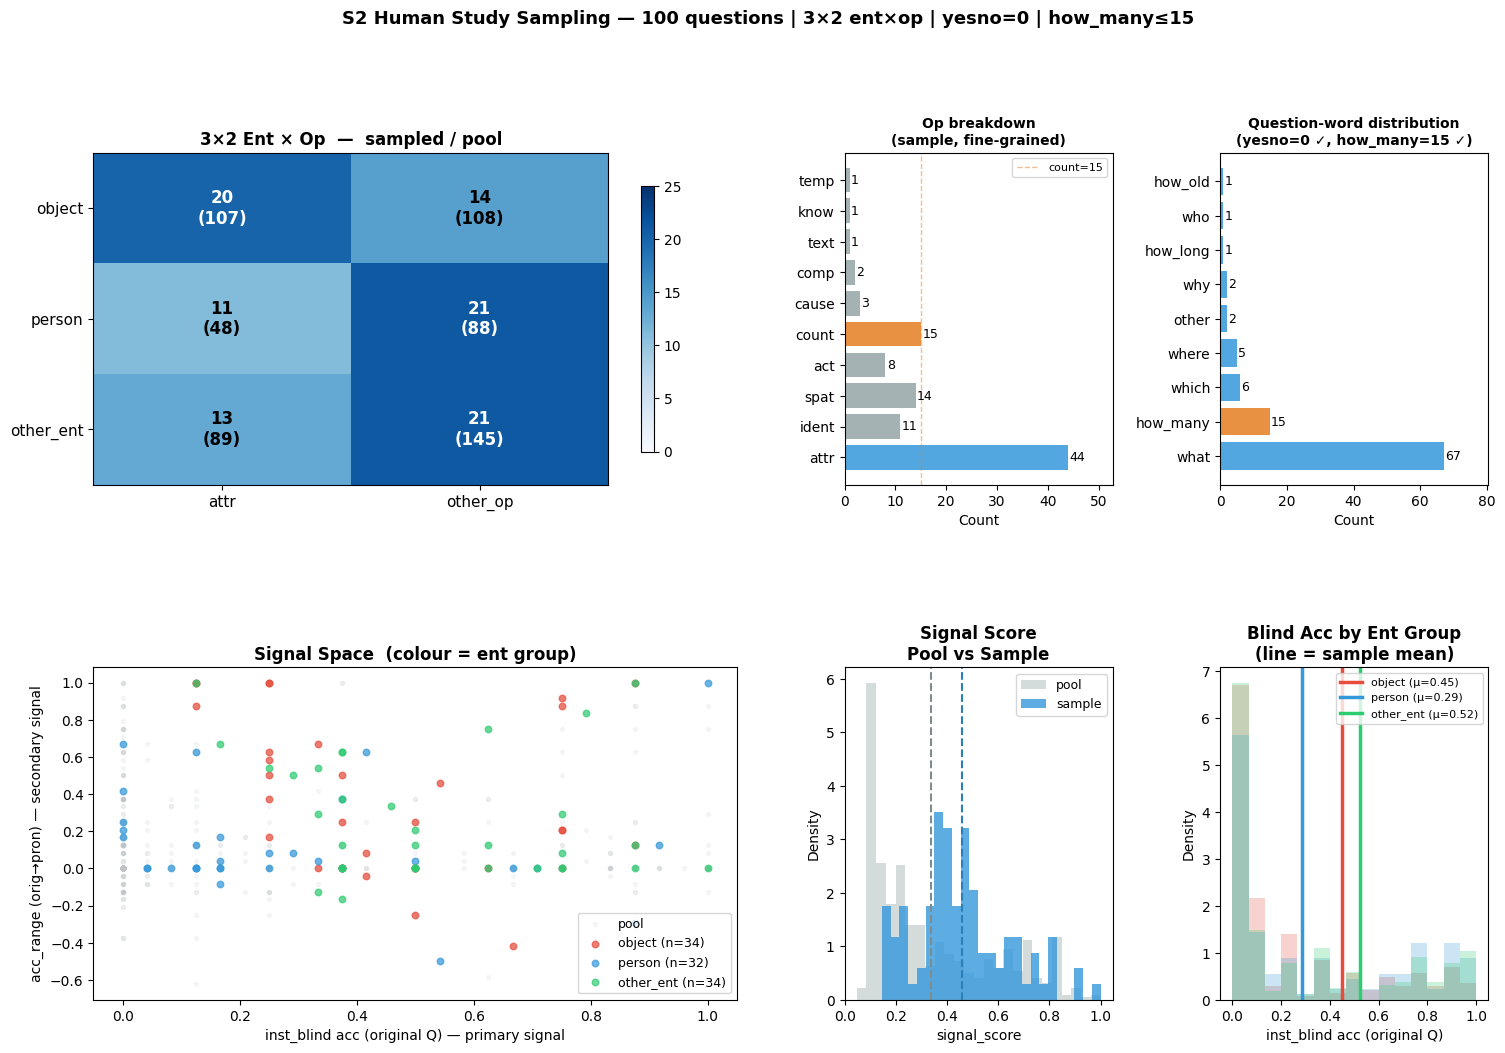

Saved: /home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

ENT_ORD   = ['object', 'person', 'animal', 'scene', 'misc']
OP_ORD_2  = ['attr', 'other_op']              # actual grid groups
OP_FINE   = ['attr','ident','spat','act','count','cause','comp','text','know','temp','other']
ENT_COLORS = {
    'object': '#e74c3c', 'person': '#3498db', 'animal': '#f39c12',
    'scene':  '#27ae60', 'misc':   '#9b59b6',
}

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.55, wspace=0.4)

# ── (0, 0-1) 5×2 grid: selected / pool ─────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
pool_ct = nf.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0)
samp_ct = sampled.groupby(['ent_grp','op_grp']).size().unstack(fill_value=0)
pool_ct = pool_ct.reindex(index=ENT_ORD, columns=OP_ORD_2, fill_value=0)
samp_ct = samp_ct.reindex(index=ENT_ORD, columns=OP_ORD_2, fill_value=0)
im = ax0.imshow(samp_ct.values, cmap='Blues', aspect='auto', vmin=0, vmax=20)
for r in range(len(ENT_ORD)):
    for c in range(2):
        sv, pv = samp_ct.values[r, c], pool_ct.values[r, c]
        ax0.text(c, r, f'{sv}\n({pv})', ha='center', va='center',
                 fontsize=11, color='white' if sv > 13 else 'black', fontweight='bold')
ax0.set_xticks([0, 1]); ax0.set_xticklabels(OP_ORD_2, fontsize=11)
ax0.set_yticks(range(len(ENT_ORD))); ax0.set_yticklabels(ENT_ORD, fontsize=11)
ax0.set_title('5×2 Ent × Op  —  sampled / pool', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax0, shrink=0.8)

# ── (0, 2) Fine-grained op breakdown — sample only ──────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
fine_counts = sampled['op'].value_counts()
ops_present = [o for o in OP_FINE if o in fine_counts]
vals = [fine_counts.get(o, 0) for o in ops_present]
colors_op = ['#3498db' if o == 'attr' else
             '#e67e22' if o == 'count' else '#95a5a6' for o in ops_present]
bars = ax1.barh(ops_present, vals, color=colors_op, alpha=0.85)
for bar, v in zip(bars, vals):
    ax1.text(v + 0.3, bar.get_y() + bar.get_height()/2,
             str(v), va='center', fontsize=9)
ax1.set_xlabel('Count'); ax1.set_xlim(0, max(vals) * 1.2)
ax1.set_title('Op breakdown\n(sample, fine-grained)', fontweight='bold', fontsize=10)
ax1.axvline(15, color='#e67e22', ls='--', lw=1, alpha=0.5, label='count=15')
ax1.legend(fontsize=8)

# ── (0, 3) Question-word breakdown — sample only ────────────────────────────
ax2 = fig.add_subplot(gs[0, 3])
w_counts = sampled['w'].value_counts()
w_colors = ['#e74c3c' if w == 'yesno' else
            '#e67e22' if w == 'how_many' else '#3498db' for w in w_counts.index]
ax2.barh(w_counts.index, w_counts.values, color=w_colors, alpha=0.85)
for i, v in enumerate(w_counts.values):
    ax2.text(v + 0.3, i, str(v), va='center', fontsize=9)
ax2.set_xlabel('Count'); ax2.set_xlim(0, w_counts.max() * 1.2)
ax2.set_title('Question-word distribution\n(yesno=0 ✓, how_many≤15 ✓)', fontweight='bold', fontsize=10)

# ── (1, 0-1) Signal space: inst_blind acc vs acc_range ──────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.scatter(nf['inst_acc_orig'], nf['acc_range'], alpha=0.12, s=8, c='#bdc3c7', label='pool')
for ent, col in ENT_COLORS.items():
    s = sampled[sampled['ent_grp'] == ent]
    if len(s) == 0: continue
    ax3.scatter(s['inst_acc_orig'], s['acc_range'], alpha=0.7, s=22,
                c=col, zorder=3, label=f'{ent} (n={len(s)})')
ax3.set_xlabel('inst_blind acc (original Q) — primary signal')
ax3.set_ylabel('acc_range (orig→pron) — secondary signal')
ax3.set_title('Signal Space  (colour = ent group)', fontweight='bold')
ax3.legend(fontsize=8, ncol=2)

# ── (1, 2) Signal score dist: pool vs sample ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(nf['signal_score'],       bins=25, alpha=0.4, color='#95a5a6', label='pool',   density=True)
ax4.hist(sampled['signal_score'],  bins=25, alpha=0.8, color='#3498db', label='sample', density=True)
ax4.axvline(nf['signal_score'].mean(),      color='#7f8c8d', ls='--', lw=1.5)
ax4.axvline(sampled['signal_score'].mean(), color='#2980b9', ls='--', lw=1.5)
ax4.set_xlabel('signal_score'); ax4.set_ylabel('Density')
ax4.set_title('Signal Score\nPool vs Sample', fontweight='bold')
ax4.legend(fontsize=9)

# ── (1, 3) inst_blind acc dist by ent group ─────────────────────────────────
ax5 = fig.add_subplot(gs[1, 3])
for ent, col in ENT_COLORS.items():
    vals  = nf[nf['ent_grp'] == ent]['inst_acc_orig'].dropna().values
    svals = sampled[sampled['ent_grp'] == ent]['inst_acc_orig'].dropna().values
    if len(vals) == 0: continue
    ax5.hist(vals, bins=15, alpha=0.25, color=col, density=True)
    mu = svals.mean() if len(svals) > 0 else float('nan')
    ax5.axvline(mu, color=col, lw=2.5, label=f'{ent} (μ={mu:.2f})')
ax5.set_xlabel('inst_blind acc (original Q)'); ax5.set_ylabel('Density')
ax5.set_title('Blind Acc by Ent Group\n(line = sample mean)', fontweight='bold')
ax5.legend(fontsize=7, ncol=1)

plt.suptitle(
    f'S2 Human Study Sampling — {N_SAMPLE} questions | 5×2 ent×op | yesno=0 | how_many≤15',
    fontsize=13, fontweight='bold', y=1.01
)
fig_path = '/home/david/Desktop/yuna/HPA/analysis/figures/sampling_3x3_stratified.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')


In [7]:
# ── Statistical Power Analysis ────────────────────────────────────────────────
import scipy.stats as stats
from scipy.stats import norm as snorm

N_Q, N_R, N_CT, ALPHA = len(sampled), 25, 3, 0.05
N_CELLS = 9                    # 3×3, 11-12 Qs per cell
N_PER_CELL_Q = N_Q // N_CELLS  # ≈ 11

def pw_r(n, r):
    z = np.arctanh(r); se = 1 / np.sqrt(n - 3)
    return snorm.cdf(abs(z) / se - snorm.ppf(1 - ALPHA/2))

def pw_paired(n, d):
    return snorm.cdf(abs(d) * np.sqrt(n) - snorm.ppf(1 - ALPHA/2))

def pw_2samp(n, d):
    return snorm.cdf(abs(d) / np.sqrt(2 / n) - snorm.ppf(1 - ALPHA/2))

print('=' * 62)
print(f'  Power Analysis  |  N_q={N_Q}  N_raters={N_R}  N_variants={N_CT}')
print('=' * 62)

# ── PRIMARY: correlation human difficulty vs model ────────────────────────────
# From existing study: observed r = 0.50–0.72 (inst_blind), so expected ≈ 0.50+
print('\n[PRIMARY] Correlation: human difficulty curve vs model accuracy')
print('          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study')
for r in [0.20, 0.30, 0.40, 0.50, 0.60]:
    pw = pw_r(N_Q, r)
    flag = '✓' if pw >= 0.8 else '✗ below threshold'
    print(f'  r={r:.2f}: power={pw:.3f}  {flag}')
print('  Detection floor: r ≥ 0.30 at power=0.80')
print('  → N=100 is sufficient given expected effect sizes.')

# ── SECONDARY: human degradation across 3 variants ───────────────────────────
print('\n[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)')
print('    One-way ANOVA equivalent / paired t for each step:')
for d in [0.2, 0.3, 0.5]:
    pw = pw_paired(N_Q, d)
    print(f'  d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "✗"}')

# ── TERTIARY: cell-level descriptive ─────────────────────────────────────────
print(f'\n[3] Cell-level comparisons  (11 Qs/cell = {N_PER_CELL_Q*N_R} responses/cell)')
print('    (a) Question-level t-test (n=11 per cell) — NOT recommended:')
for d in [0.5, 0.8]:
    print(f'        d={d:.1f}: power={pw_2samp(N_PER_CELL_Q,d):.3f}  ← weak')
print('    (b) Response-level LMM (n=275 responses per cell):')
for d in [0.2, 0.3]:
    pw = pw_2samp(N_PER_CELL_Q*N_R, d)
    print(f'        d={d:.1f}: power={pw:.3f}  {"✓" if pw>=0.8 else "~"}')
print('    → Use 3×3 cells for descriptive stratification,')
print('      not for inferential comparisons. Primary claim is correlation.')

# ── Study burden ──────────────────────────────────────────────────────────────
print(f'\n[Study burden]')
print(f'  Items per rater: {N_Q} Qs × {N_CT} variants = {N_Q*N_CT}  (~55–75 min)')
print(f'  Total responses: {N_Q} × {N_CT} × {N_R} = {N_Q*N_CT*N_R:,}')

# ── ICC extrapolation ─────────────────────────────────────────────────────────
icc0, k0 = 0.963, 20
rho1 = icc0 / (k0 - (k0-1)*icc0)
print(f'\n[ICC] Extrapolated from existing study (ICC=0.963, k=20):')
for k in [20, 25, 30]:
    icc_k = k*rho1/(1+(k-1)*rho1)
    print(f'  k={k}: ICC≈{icc_k:.3f}  ✓')

print('\n' + '=' * 62)
print('Verdict:')
print('  ✓  Primary (correlation, r≥0.30): N=100 sufficient')
print('  ✓  Degradation (paired, d≥0.30): N=100 sufficient')
print('  ⚠  Cell-level t-tests at question level: underpowered (n=11)')
print('  ✓  Response-level LMM with rater random effect: d≥0.3 detectable')
print('  ✓  3×3 stratification provides coverage diversity, not inferential cells')

print()
print('=== Analysis design separation ===')
print('  ent×op cell characterization → MODEL analysis (§4-5)')
print('    Use full 1K dataset × 8 models: well-powered for all cells')
print('    Already in analysis-pretrained.ipynb / abstention_analysis.ipynb')
print()
print('  Human-model alignment → HUMAN study (§6)')
print('    N=100 Qs × 25 raters: powered for correlation (primary)')
print('    3×3 stratification = sampling diversity, NOT inferential grouping')
print()
print('  Do NOT attempt per-cell human analysis (11 Qs/cell → underpowered)')


  Power Analysis  |  N_q=100  N_raters=25  N_variants=3

[PRIMARY] Correlation: human difficulty curve vs model accuracy
          Unit = question (N=100)  |  Expected r ≈ 0.50–0.62 from existing study
  r=0.20: power=0.515  ✗ below threshold
  r=0.30: power=0.862  ✓
  r=0.40: power=0.987  ✓
  r=0.50: power=1.000  ✓
  r=0.60: power=1.000  ✓
  Detection floor: r ≥ 0.30 at power=0.80
  → N=100 is sufficient given expected effect sizes.

[2] Human degradation: orig → weaker_obj → pron  (repeated-measures, N=100 Qs)
    One-way ANOVA equivalent / paired t for each step:
  d=0.2: power=0.516  ✗
  d=0.3: power=0.851  ✓
  d=0.5: power=0.999  ✓

[3] Cell-level comparisons  (11 Qs/cell = 275 responses/cell)
    (a) Question-level t-test (n=11 per cell) — NOT recommended:
        d=0.5: power=0.216  ← weak
        d=0.8: power=0.467  ← weak
    (b) Response-level LMM (n=275 responses per cell):
        d=0.2: power=0.650  ~
        d=0.3: power=0.940  ✓
    → Use 3×3 cells for descriptive strati

---

## Which Control Types to Show Humans

### Degradation ladder (5 steps)

| Variant | Example | Human signal | Model signal | Verdict |
|---------|---------|-------------|--------------|---------|
| `question` | "How many dogs are in the park?" | Baseline (linguistic priors) | Baseline | **Include** |
| `deictic_removed` | "How many dogs in the park?" *(no 'this/that')* | ≈ identical to original | Minor | **Skip** — trivially easy |
| `object_removed` | "How many **objects** are in the park?" | Unanswerable — humans say "can't tell" | Strong | **Skip** — disrupts prior activation |
| `weaker_object` | "How many **animals** are in the park?" | Partial — hypernym primes partial knowledge | Clear midpoint | **Include** |
| `pronominalized` | "How many of **them** are in the park?" | Near-chance — zero entity info | Endpoint | **Include** |

### Recommendation: **3 variants — `question`, `weaker_object`, `pronominalized`**

**Why these 3:**
- Endpoints (`question`, `pronominalized`) establish the degradation effect — required for the core claim
- `weaker_object` reveals *where* the cliff is: after the hypernym or only after the pronoun? This separates referential grounding from semantic class knowledge
- Skipping `deictic_removed` (no human signal) and `object_removed` (disrupts prior activation rather than testing it) keeps the burden minimal

### Final study design

| Parameter | Value | Notes |
|-----------|-------|-------|
| Questions | **100** | 11–12 per ent×op cell (3×3 grid) |
| Variants per question | **3** (question · weaker_object · pronominalized) | |
| Raters | **25** | All see the same 100 questions |
| Items per rater | **300** | ~55–75 min |
| Total responses | **7,500** | |
| Primary analysis | Pearson r: human difficulty vs model accuracy | N=100 Qs; detection floor r≥0.30 |
| Secondary analysis | Repeated-measures: degradation orig→weaker→pron | d≥0.30, power=0.85 |
| Tertiary | LMM with ent/op group interactions | `accuracy ~ variant × ent_grp + (1|q) + (1|rater)` |
| 3×3 grid purpose | Coverage diversity | Not powered for inferential cell comparisons |

**Note on human vs LLM substitution:** the correlation target is model behavior from the logit
inference runs — human responses are irreplaceable here. An LLM generating "human-like"
answers would just reproduce model priors, not human linguistic priors.


In [8]:
# ── Save final sample ─────────────────────────────────────────────────────────
OUT_PATH = '/home/david/Desktop/yuna/HPA/experiment/s2_v2/s2.csv'  # v2 path

save_cols = [
    'question_id', 'question_text', 'ent', 'op', 'ent_grp', 'op_grp', 'cell',
    'acc_original', 'acc_pronominalized', 'acc_range', 'acc_std', 'n_unique',
    'signal_score', 'inst_acc_orig', 'inst_acc_range',
]
# pull question_text from sem_df if not already in sampled
if 'question_text' not in sampled.columns:
    sampled = sampled.merge(sem_df[['question_id']], on='question_id', how='left') # ,'question' 
    sampled = sampled.rename(columns={'question': 'question_text'})

final_cols = [c for c in save_cols if c in sampled.columns]
sampled[final_cols].to_csv(OUT_PATH, index=False)

print(f"Saved {len(sampled)} questions → {OUT_PATH}")
print(f"\nControl types to show humans: question · weaker_object · pronominalized")
print(f"Study burden: {len(sampled)} Qs × 3 variants × 25 raters = {len(sampled)*3*25:,} total responses")
print(f"\nSample summary:")
print(sampled[['ent_grp','op_grp','acc_range','acc_std','n_unique','signal_score']].describe().round(3))


Saved 100 questions → /home/david/Desktop/yuna/HPA/experiment/s2.csv

Control types to show humans: question · weaker_object · pronominalized
Study burden: 100 Qs × 3 variants × 25 raters = 7,500 total responses

Sample summary:
       acc_range  acc_std  n_unique  signal_score
count    100.000  100.000   100.000       100.000
mean       0.250    0.153     4.140         0.457
std        0.357    0.142     2.648         0.189
min       -0.500    0.000     1.000         0.145
25%        0.000    0.017     2.000         0.354
50%        0.125    0.113     4.000         0.423
75%        0.500    0.250     5.000         0.559
max        1.000    0.490    16.000         1.000


---

## Flat Questions — Supplementary Addition

**Definition:** A question is *flat* if every model gives the **same answer across all 5 control types** under blind condition.

**Pool stats:** 204 flat non-yes/no questions in the 1k pool — 66 in S1, 27 in prior S2 sample, 111 available.

**10 selected for S2** (added to `s2_pronominalized.json` as variant A, IDs 301–310).

In [ ]:
# ── Flat question analysis ─────────────────────────────────────────────────────
import pathlib
FLAT_PATH = pathlib.Path('/home/david/Desktop/yuna/HPA/experiment/flat_questions.csv')
flat_df = pd.read_csv(FLAT_PATH)

pool_total     = len(flat_df)
pool_in_s1     = flat_df['in_s1'].sum()
pool_in_s2     = flat_df['in_s2'].sum()
pool_available = ((~flat_df['in_s1']) & (~flat_df['in_s2'])).sum()

print(f'Flat question pool (non-yes/no): {pool_total}')
print(f'  in S1 (human study):  {pool_in_s1}')
print(f'  in S2 sample:         {pool_in_s2}')
print(f'  available (neither):  {pool_available}')
print()

# The 10 newly added flat questions
newly_added_qids = [117237001, 36032002, 192817002, 104025000, 246883002,
                    50746005, 23201004, 206705005, 577870001, 500100006]
new_flat = flat_df[flat_df['question_id'].isin(newly_added_qids)].copy()

MODEL_COLS = ['Qwen3-8B_blind_ans', 'LLaVA-Mistral_blind_ans', 'LLaVA-1.5_blind_ans', 'LLaVA-Vicuna_blind_ans']
display_cols = ['question_id', 'op', 'ent', 'avg_blind_acc', 'avg_inst_blind_acc'] + MODEL_COLS + ['question']
print('10 flat questions added to S2 (pronominalized variant only):')
print(new_flat[display_cols].to_string(index=False, max_colwidth=45))
print()
print(f'Avg blind acc:      {new_flat["avg_blind_acc"].mean():.3f}')
print(f'Avg inst_blind acc: {new_flat["avg_inst_blind_acc"].mean():.3f}')
print()
print('Notable patterns:')
for _, row in new_flat.sort_values('avg_blind_acc', ascending=False).iterrows():
    consensus = row['Qwen3-8B_blind_ans']
    acc = row['avg_blind_acc']
    flag = 'correct' if acc >= 0.5 else ('wrong' if acc == 0 else 'partial')
    print(f'  [{flag}] "{row["question"]}" -> all models say "{consensus}" (acc={acc:.2f})')
